# 🎬 Khám Phá và Phân Tích Dữ Liệu Netflix (EDA)
### **Nhóm 8 - KADA**
**Thành viên:** Phạm Nguyễn Hải Triều, Lương Võ Khôi Quốc, Mô Ha Mách Bu Ba Ka, Trần Quốc Huy, Nguyễn Chí Thịnh

> **Ghi chú:** Notebook này hỗ trợ phân tích trực tiếp trên cả 2 tệp:
> - `netflix_titles_cleaned.csv` *(Tệp dữ liệu đã làm sạch & chuẩn hóa)*
> - `netflix_titles.csv` *(Tệp dữ liệu gốc)*

## 1. Import Thư Viện và Cấu Hình Hệ Thống

In [6]:
import os
os.environ['OPENBLAS_NUM_THREADS'] = '1'
os.environ['OMP_NUM_THREADS'] = '1'
os.environ['MKL_NUM_THREADS'] = '1'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Thiết lập phong cách hiển thị
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
sns.set_palette('tab10')
plt.rcParams['figure.figsize'] = (10, 6)
%matplotlib inline

## 2. Nạp Dữ Liệu (Tự động ưu tiên file đã làm sạch `netflix_titles_cleaned.csv`)

In [7]:
# Tự động phát hiện tệp đã làm sạch hoặc tệp gốc
data_file = 'netflix_titles_cleaned.csv' if os.path.exists('netflix_titles_cleaned.csv') else 'netflix_titles.csv'
print(f"Đang sử dụng tệp dữ liệu: {data_file}")

df = pd.read_csv(data_file)
print(f"Kích thước dữ liệu: {df.shape[0]:,} dòng x {df.shape[1]} cột\n")
df.head()

Đang sử dụng tệp dữ liệu: netflix_titles_cleaned.csv
Kích thước dữ liệu: 8,807 dòng x 18 cột



,show_id,type,title,director,cast,cast_count,country,primary_country,date_added,year_added,month_added,release_year,rating,duration_int,duration_unit,listed_in,primary_genre,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,0,United States,United States,2021-09-25,2021,9,2020,PG-13,90,min,Documentaries,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",19,South Africa,South Africa,2021-09-24,2021,9,2021,TV-MA,2,Seasons,"International TV Shows, TV Dramas, TV Mysteries",International TV Shows,"After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",9,Unknown,Unknown,2021-09-24,2021,9,2021,TV-MA,1,Season,"Crime TV Shows, International TV Shows, TV Act...",Crime TV Shows,To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,0,Unknown,Unknown,2021-09-24,2021,9,2021,TV-MA,1,Season,"Docuseries, Reality TV",Docuseries,"Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",8,India,India,2021-09-24,2021,9,2021,TV-MA,2,Seasons,"International TV Shows, Romantic TV Shows, TV ...",International TV Shows,In a city of coaching centers known to train I...


In [8]:
# Kiểm tra thông tin các trường và kiểu dữ liệu
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   show_id          8807 non-null   object
 1   type             8807 non-null   object
 2   title            8807 non-null   object
 3   director         8807 non-null   object
 4   cast             8807 non-null   object
 5   cast_count       8807 non-null   int64 
 6   country          8807 non-null   object
 7   primary_country  8807 non-null   object
 8   date_added       8807 non-null   object
 9   year_added       8807 non-null   int64 
 10  month_added      8807 non-null   int64 
 11  release_year     8807 non-null   int64 
 12  rating           8807 non-null   object
 13  duration_int     8807 non-null   int64 
 14  duration_unit    8807 non-null   object
 15  listed_in        8807 non-null   object
 16  primary_genre    8807 non-null   object
 17  description      8807 non-null   

In [9]:
# Kiểm tra các giá trị null còn lại
null_counts = df.isnull().sum()
print("Số lượng giá trị thiếu theo từng cột:")
print(null_counts[null_counts > 0] if (null_counts > 0).any() else "Tuyệt vời! Không còn giá trị thiếu nào.")

Số lượng giá trị thiếu theo từng cột:
Tuyệt vời! Không còn giá trị thiếu nào.


## 3. Đảm Bảo Dữ Liệu Đồng Nhất (Chuẩn Hóa Nếu Đọc File Gốc)

In [10]:
df_clean = df.copy()

# Đảm bảo luôn có các trường cần thiết nếu chạy trên file gốc
if 'duration_int' not in df_clean.columns:
    df_clean['duration_int'] = df_clean['duration'].str.extract('(\d+)').astype(float).fillna(0).astype(int)
if 'primary_country' not in df_clean.columns:
    df_clean['country'] = df_clean['country'].fillna('Unknown')
    df_clean['primary_country'] = df_clean['country'].apply(lambda x: x.split(',')[0].strip())
if 'year_added' not in df_clean.columns:
    df_clean['date_added'] = pd.to_datetime(df_clean['date_added'].astype(str).str.strip(), format='%B %d, %Y', errors='coerce')
    df_clean['year_added'] = df_clean['date_added'].dt.year.fillna(df_clean['release_year']).astype(int)

print("Dữ liệu đã sẵn sàng để phân tích trực quan!")

Dữ liệu đã sẵn sàng để phân tích trực quan!


## 4. Trực Quan Hóa và Phân Tích Chuyên Sâu (Visualizations)

### 4.1 Tỷ Lệ Phim Lẻ (Movie) và Phim Bộ (TV Show)

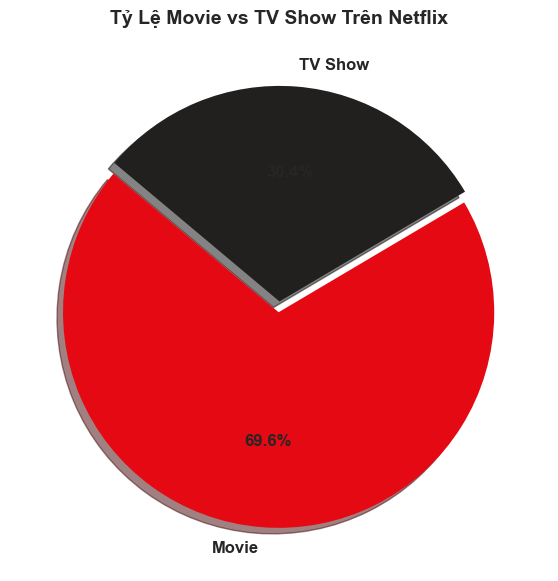

In [11]:
plt.figure(figsize=(7, 7))
type_counts = df_clean['type'].value_counts()
colors = ['#e50914', '#221f1f']
plt.pie(type_counts, labels=type_counts.index, autopct='%1.1f%%', startangle=140, colors=colors,
        explode=[0.05, 0], shadow=True, textprops={'fontsize': 12, 'weight': 'bold'})
plt.title('Tỷ Lệ Movie vs TV Show Trên Netflix', fontsize=14, weight='bold')
plt.show()

### 4.2 Xu Hướng Tăng Trưởng Nội Dung Qua Các Năm

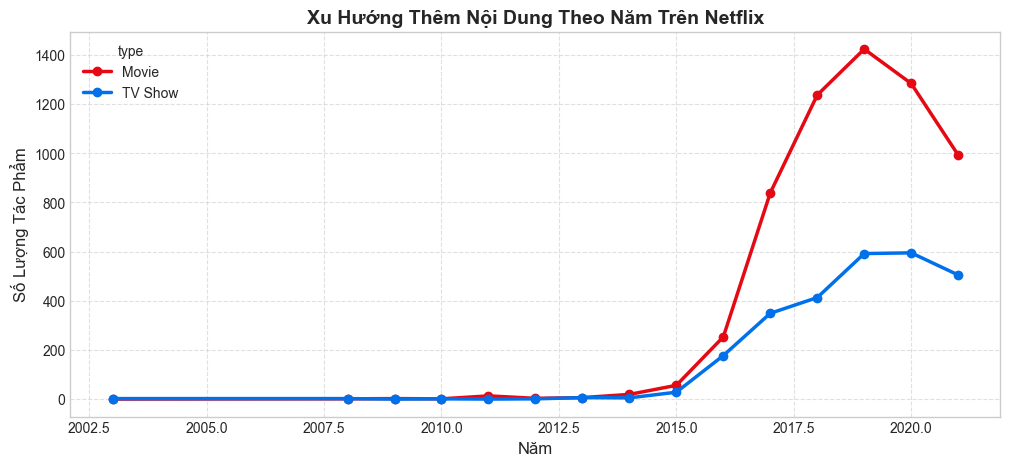

In [12]:
plt.figure(figsize=(12, 5))
yearly_trend = df_clean.groupby(['year_added', 'type']).size().unstack().fillna(0)
yearly_trend.plot(kind='line', marker='o', linewidth=2.5, color=['#e50914', '#0071eb'], ax=plt.gca())
plt.title('Xu Hướng Thêm Nội Dung Theo Năm Trên Netflix', fontsize=14, weight='bold')
plt.xlabel('Năm', fontsize=12)
plt.ylabel('Số Lượng Tác Phẩm', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### 4.3 Top 10 Quốc Gia Sản Xuất Nội Dung Nhiều Nhất

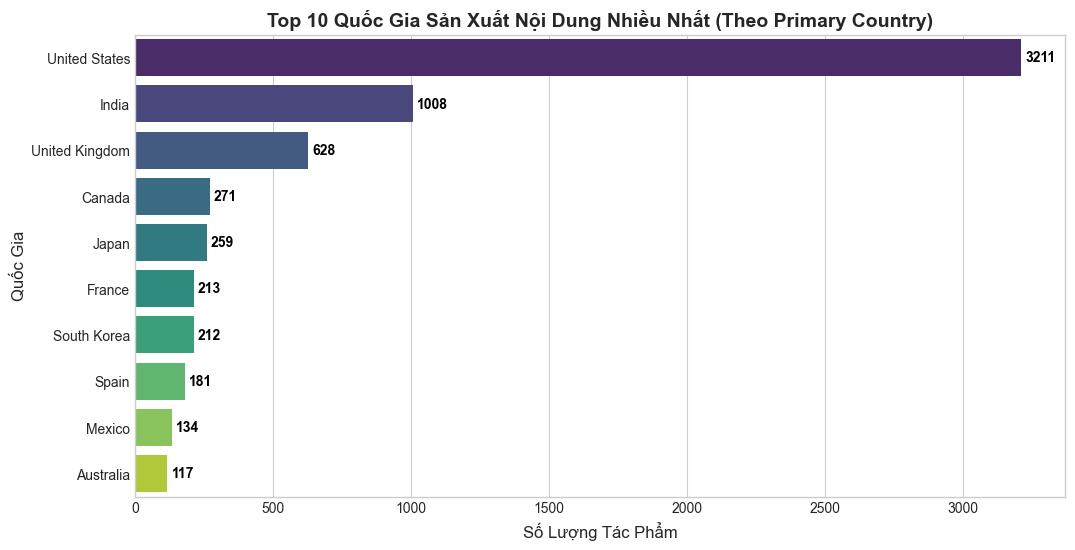

In [13]:
plt.figure(figsize=(12, 6))
top_countries = df_clean[df_clean['primary_country'] != 'Unknown']['primary_country'].value_counts().head(10)
sns.barplot(x=top_countries.values, y=top_countries.index, palette='viridis', hue=top_countries.index, legend=False)
plt.title('Top 10 Quốc Gia Sản Xuất Nội Dung Nhiều Nhất (Theo Primary Country)', fontsize=14, weight='bold')
plt.xlabel('Số Lượng Tác Phẩm', fontsize=12)
plt.ylabel('Quốc Gia', fontsize=12)
for i, v in enumerate(top_countries.values):
    plt.text(v + 15, i, str(v), color='black', va='center', fontweight='bold')
plt.show()

### 4.4 Phân Bổ Độ Tuổi (Rating) Theo Loại Nội Dung

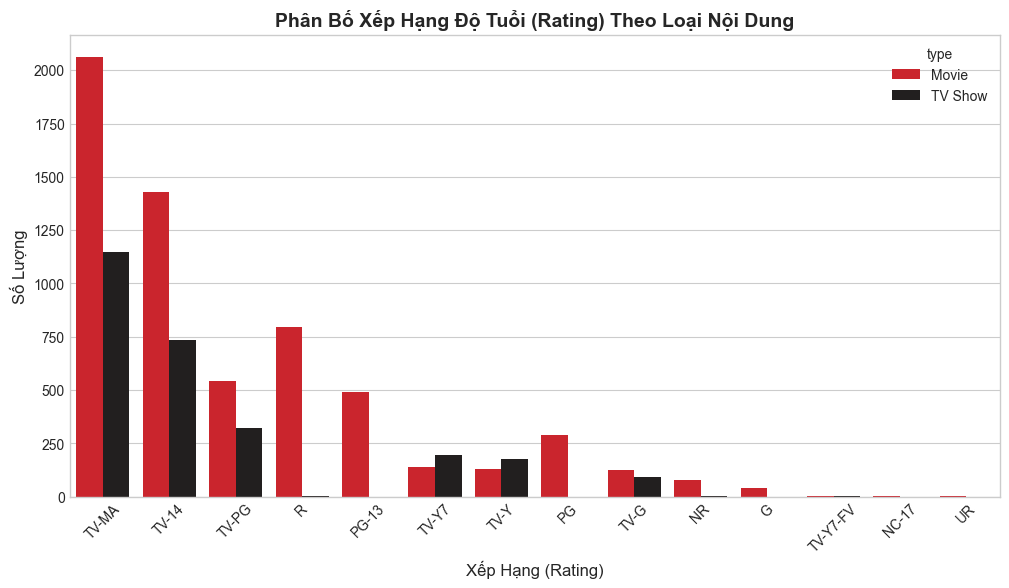

In [14]:
plt.figure(figsize=(12, 6))
rating_order = df_clean['rating'].value_counts().index
sns.countplot(data=df_clean, x='rating', order=rating_order, hue='type', palette={'Movie': '#e50914', 'TV Show': '#221f1f'})
plt.title('Phân Bố Xếp Hạng Độ Tuổi (Rating) Theo Loại Nội Dung', fontsize=14, weight='bold')
plt.xlabel('Xếp Hạng (Rating)', fontsize=12)
plt.ylabel('Số Lượng', fontsize=12)
plt.xticks(rotation=45)
plt.show()

### 4.5 Phân Bố Thời Lượng Phim Lẻ (Movie Duration)

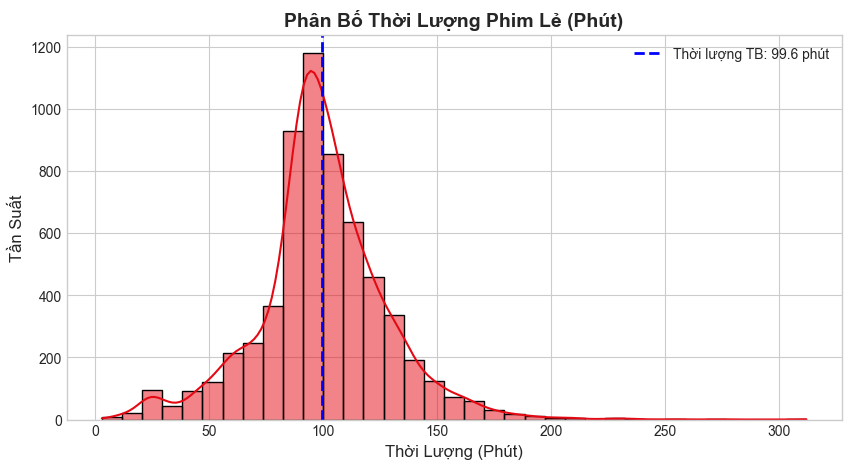

In [15]:
plt.figure(figsize=(10, 5))
movies_df = df_clean[df_clean['type'] == 'Movie']
sns.histplot(movies_df['duration_int'], kde=True, bins=35, color='#e50914')
mean_val = movies_df['duration_int'].mean()
plt.axvline(mean_val, color='blue', linestyle='dashed', linewidth=2, label=f'Thời lượng TB: {mean_val:.1f} phút')
plt.title('Phân Bố Thời Lượng Phim Lẻ (Phút)', fontsize=14, weight='bold')
plt.xlabel('Thời Lượng (Phút)', fontsize=12)
plt.ylabel('Tần Suất', fontsize=12)
plt.legend()
plt.show()

### 4.6 Top 10 Thể Loại Phim Phổ Biến Nhất

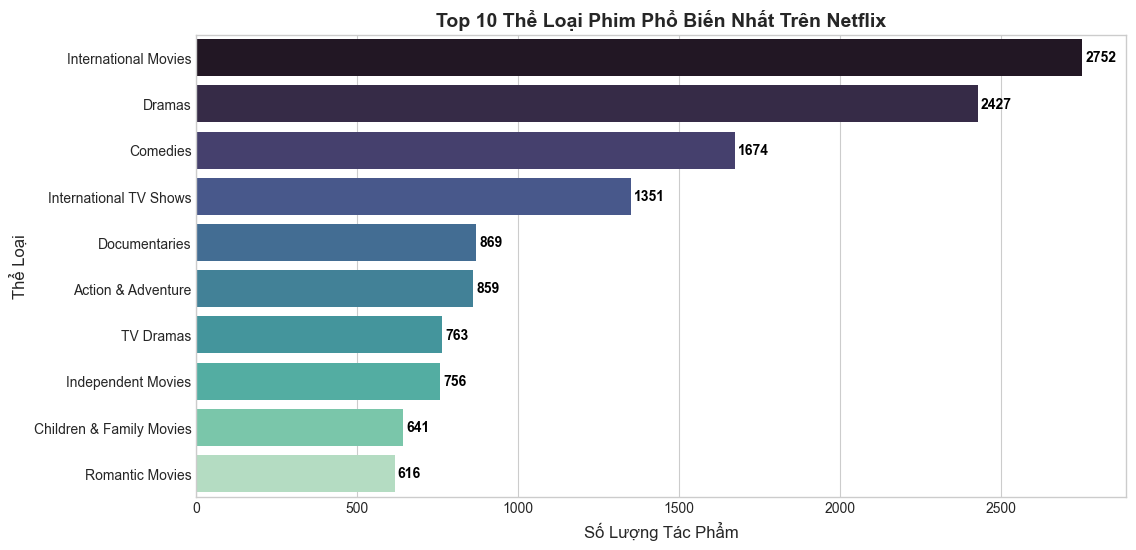

In [16]:
plt.figure(figsize=(12, 6))
top_genres = df_clean['listed_in'].str.split(', ').explode().value_counts().head(10)
sns.barplot(x=top_genres.values, y=top_genres.index, palette='mako', hue=top_genres.index, legend=False)
plt.title('Top 10 Thể Loại Phim Phổ Biến Nhất Trên Netflix', fontsize=14, weight='bold')
plt.xlabel('Số Lượng Tác Phẩm', fontsize=12)
plt.ylabel('Thể Loại', fontsize=12)
for i, v in enumerate(top_genres.values):
    plt.text(v + 10, i, str(v), color='black', va='center', fontweight='bold')
plt.show()

## 5. Machine Learning: Hệ Thống Gợi Ý Phim Dựa Trên Nội Dung (TF-IDF & Cosine Similarity)

In [17]:
# Kết hợp thông tin thể loại và tóm tắt nội dung
df_clean['features'] = df_clean['listed_in'].fillna('') + ' ' + df_clean['description'].fillna('')

# Trích xuất đặc trưng văn bản bằng TF-IDF
tfidf = TfidfVectorizer(stop_words='english', max_features=5000)
tfidf_matrix = tfidf.fit_transform(df_clean['features'])

# Tính toán ma trận độ tương đồng Cosine
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)
print(f"Kích thước ma trận tương đồng Cosine: {cosine_sim.shape}")

Kích thước ma trận tương đồng Cosine: (8807, 8807)


In [18]:
def recommend_movies(title, num_recommendations=5):
    matches = df_clean[df_clean['title'].str.lower() == title.lower()]
    if matches.empty:
        return f"Không tìm thấy phim '{title}'!"
    
    idx = matches.index[0]
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:num_recommendations+1]
    
    movie_indices = [i[0] for i in sim_scores]
    return df_clean.iloc[movie_indices][['title', 'type', 'listed_in', 'release_year', 'rating']]

# Gợi ý cho phim "Squid Game"
print("Gợi ý các phim tương tự 'Squid Game':")
recommend_movies('Squid Game')

Gợi ý các phim tương tự 'Squid Game':


,title,type,listed_in,release_year,rating
1440,Nailed It! Mexico,TV Show,"International TV Shows, Reality TV, Spanish-La...",2021,TV-PG
3684,Kakegurui,TV Show,"International TV Shows, TV Dramas, TV Thrillers",2019,TV-MA
1011,Free to Play,Movie,Documentaries,2014,TV-14
2827,The Circle Brazil,TV Show,"International TV Shows, Reality TV",2020,TV-MA
4143,Sparta,TV Show,"Crime TV Shows, International TV Shows, TV Dramas",2018,TV-MA


In [19]:
# Gợi ý cho phim khoa học viễn tưởng "Dark Skies"
print("Gợi ý các phim tương tự 'Dark Skies':")
recommend_movies('Dark Skies')

Gợi ý các phim tương tự 'Dark Skies':


,title,type,listed_in,release_year,rating
4133,Await Further Instructions,Movie,"Horror Movies, Sci-Fi & Fantasy",2018,TV-MA
2555,Aerials,Movie,"International Movies, Sci-Fi & Fantasy",2016,TV-14
779,Battlefield Earth,Movie,"Action & Adventure, Cult Movies, Sci-Fi & Fantasy",2000,PG-13
6911,Halo: The Fall of Reach,Movie,"Action & Adventure, Sci-Fi & Fantasy",2015,TV-14
3097,Doom: Annihilation,Movie,"Action & Adventure, Horror Movies, Sci-Fi & Fa...",2019,R
